In [74]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [75]:
df = pd.read_csv("insurance.csv")

In [76]:
# df.head()
df.sample(10)
# df.info()
# df.isnull()
# df.isna()
# df.tail()

,age,sex,bmi,children,smoker,region,charges
70,27,female,24.750,0,yes,southeast,16577.77950
563,50,male,44.770,1,no,southeast,9058.73030
338,50,male,32.300,1,yes,northeast,41919.09700
473,47,female,33.345,0,no,northeast,20878.78443
665,43,male,38.060,2,yes,southeast,42560.43040
785,35,female,27.700,3,no,southwest,6414.17800
509,57,female,28.700,0,no,southwest,11455.28000
1255,42,female,37.900,0,no,southwest,6474.01300
626,36,male,28.880,3,no,northeast,6748.59120
970,50,female,28.160,3,no,southeast,10702.64240


<Axes: xlabel='age', ylabel='charges'>

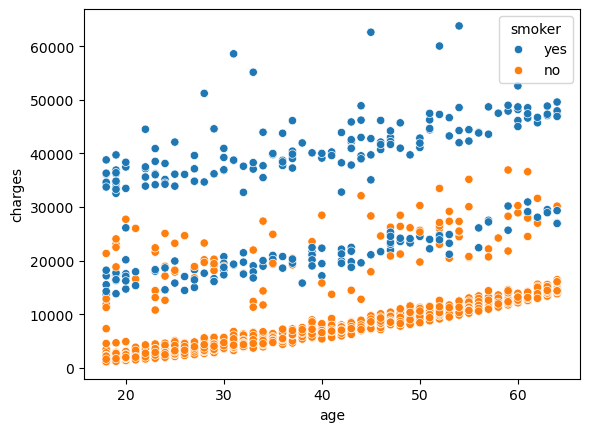

In [77]:
sns.scatterplot(data = df, x = "age", y= 'charges', hue='smoker')

In [78]:
X = df.drop(columns=["charges", "region"])
y = df["charges"]

In [81]:
X["sex"] = X["sex"].map({"female": 1, "male": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

In [83]:
X.head()

,age,sex,bmi,children,smoker
0,19,1,27.900,0,1
1,18,0,33.770,1,0
2,28,0,33.000,3,0
3,33,0,22.705,0,0
4,32,0,28.880,0,0


In [85]:
# Train Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [91]:
X_test.head()  # checking the results 

,age,sex,bmi,children,smoker
764,45,1,25.175,2,0
887,36,1,30.020,0,0
890,64,1,26.885,0,1
1293,46,0,25.745,3,0
259,19,0,31.920,0,1


In [93]:
X_train.head() # cheking the results 

,age,sex,bmi,children,smoker
560,46,1,19.95,2,0
1285,47,1,24.32,0,0
1142,52,1,24.86,0,0
969,39,1,34.32,5,0
486,54,1,21.47,3,0


In [95]:
# Train Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [97]:
# Predict values
y_pred = model.predict(X_test)

In [99]:
y_pred

array([ 8554.81711589,  6973.58746745, 36798.60416104,  9417.88282303,
       26871.68031081, 11097.38383938,   145.27608963, 16746.1683771 ,
         747.53414191, 11153.67590722, 28518.15016561,  9292.18345421,
        5460.51975119, 38510.48013003, 40359.30938604, 37223.40538064,
       15316.56711945, 36047.50032223,  9326.29049907, 31400.1559532 ,
        4269.64414373, 10464.66374097,  2719.9260555 ,  6579.53742551,
       11232.00255515, 12472.06793446, 14807.11281089,  6066.19283362,
        9535.69029723,  2377.6983797 ,  9475.05690885, 12963.23366722,
        4706.09057393,  3414.674504  ,  4815.64981654, 12484.17176954,
        2359.13614479,  9161.02061228, 33238.67621442, 32743.41702445,
        4274.58967205,  4229.5442107 , 14435.36485176, 11384.66898976,
        8925.70468583, 12480.09178788,  5154.45787816,  3554.10047649,
       35649.60942684,  9276.25523701, 15971.35991397,  2552.75200479,
       12162.99980138,  1062.65132285, 13551.43771934, 12103.65505529,
      

In [101]:
y_test

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
109     47055.53210
575     12222.89830
535      6067.12675
543     63770.42801
846      9872.70100
Name: charges, Length: 268, dtype: float64

In [103]:
# Evaluate 
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("r-squared:", r2)

n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1-r2) * (n-1) / (n-p-1))
print("adjusted r^2:", adjusted_r2)

r-squared: 0.7811302113434097
adjusted r^2: 0.7769533069797343


In [105]:
X_test.shape

(268, 5)

In [ ]:
# This is a New Model that we have trained from labeled data
and best for us that was they have gived 78% perce